In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ashydv/advertising-dataset/advertising.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/ashydv/advertising-dataset/advertising.csv')

In [7]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


**Pairplot**

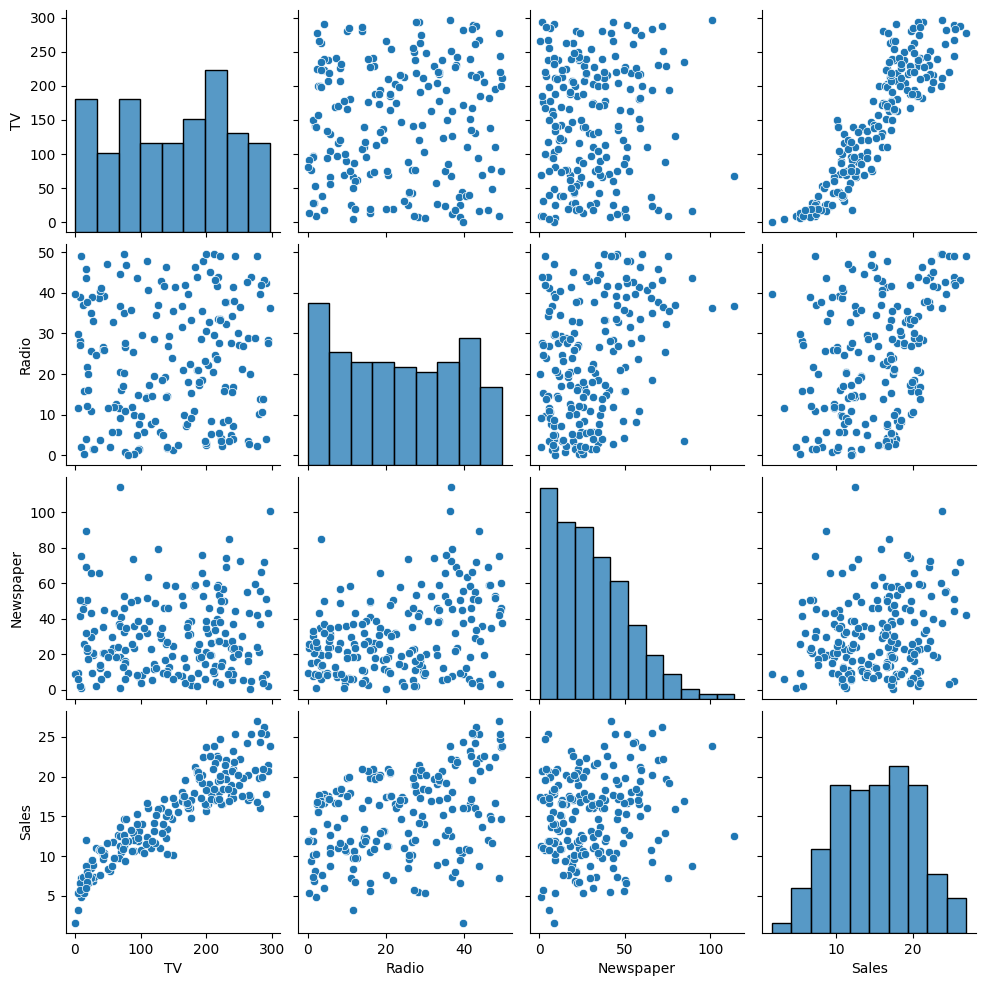

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df)

plt.show()

**Correlation Heatmap**

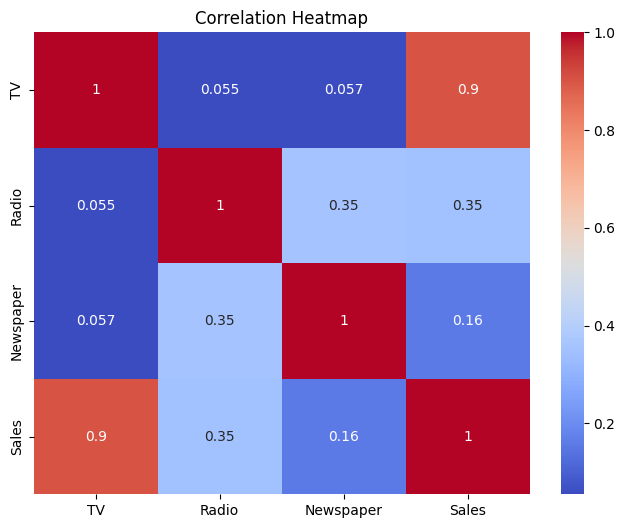

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

**Scatter Plot**

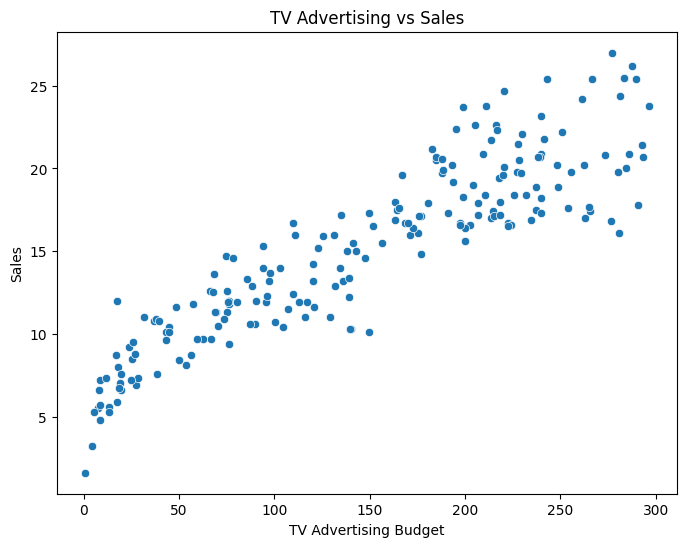

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("TV Advertising vs Sales")

plt.xlabel("TV Advertising Budget")

plt.ylabel("Sales")

plt.show()

**Histogram**

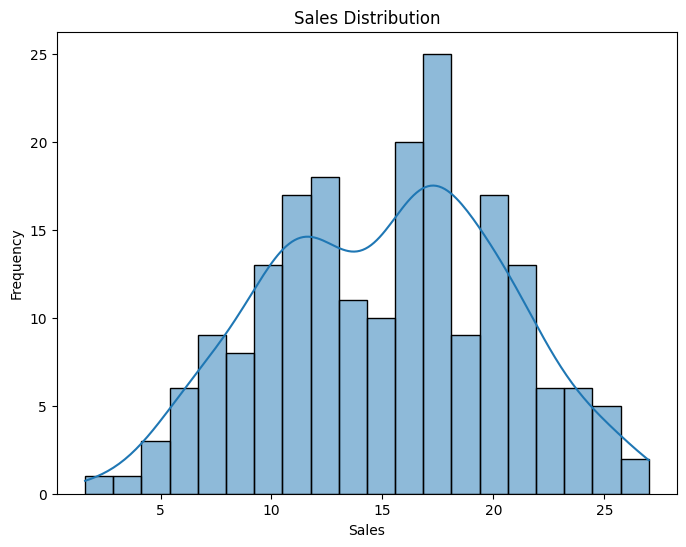

In [16]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['Sales'],
    kde=True,
    bins=20
)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

**Boxplot**

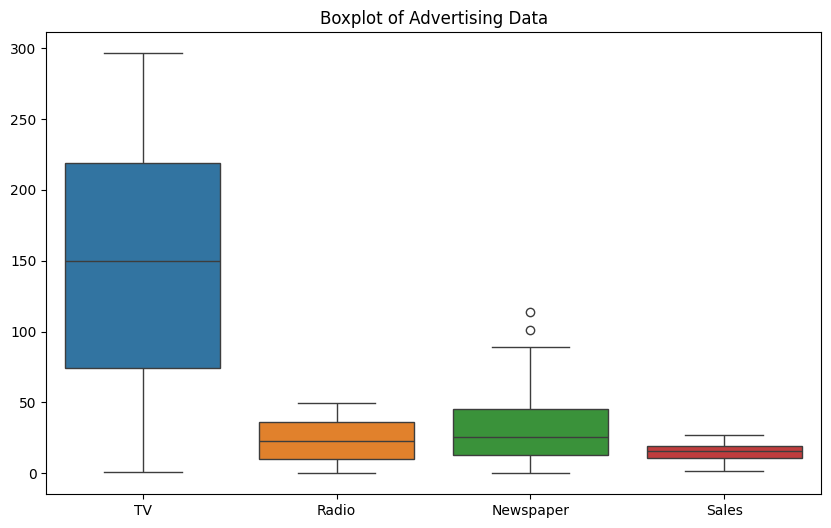

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.title("Boxplot of Advertising Data")

plt.show()

**Regression Plot**

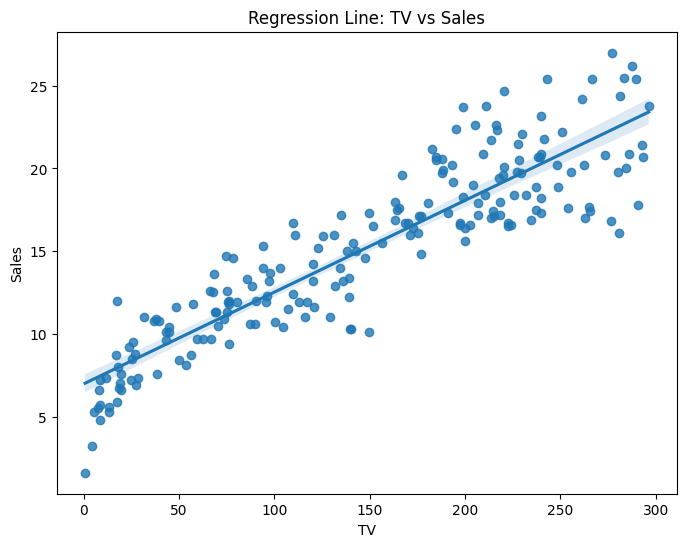

In [18]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='TV',
    y='Sales',
    data=df
)

plt.title("Regression Line: TV vs Sales")

plt.show()

**Bar Plot — Average Advertising Budget**

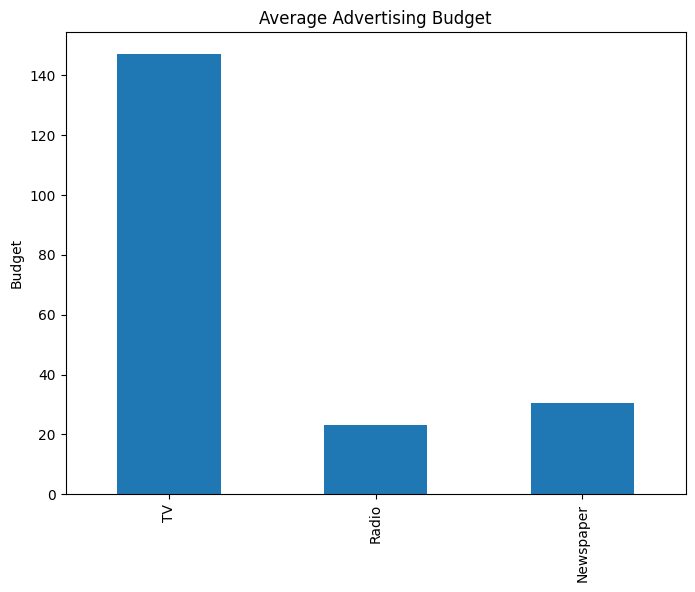

In [19]:
average_budget = df[
    ['TV', 'Radio', 'Newspaper']
].mean()

plt.figure(figsize=(8,6))

average_budget.plot(kind='bar')

plt.title("Average Advertising Budget")

plt.ylabel("Budget")

plt.show()

**Pie Chart**

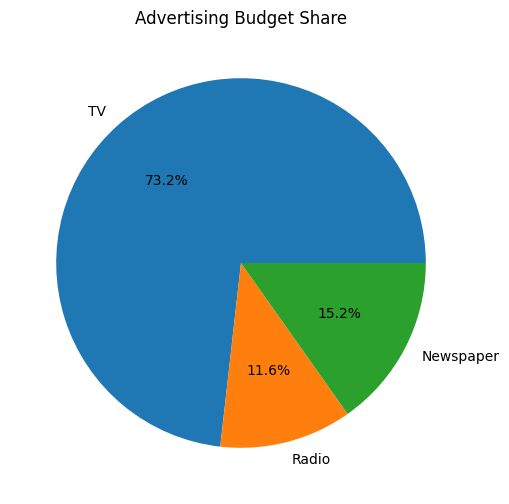

In [20]:
budget_share = df[
    ['TV', 'Radio', 'Newspaper']
].mean()

plt.figure(figsize=(6,6))

plt.pie(
    budget_share,
    labels=budget_share.index,
    autopct='%1.1f%%'
)

plt.title("Advertising Budget Share")

plt.show()

Machine Learning Model Building

In [21]:
X = df[['TV', 'Radio', 'Newspaper']]

y = df['Sales']

print("FEATURES")
print(X.head())

print("\nTARGET")
print(y.head())

FEATURES
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

TARGET
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)


In [24]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [25]:
model = LinearRegression()

print("Model Created Successfully")

Model Created Successfully


**Train Model**

In [26]:
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


**Model Coefficients**

In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337


**Intercept**

In [28]:
print("Intercept:", model.intercept_)

Intercept: 4.714126402214127


**Make Predictions**

In [29]:
y_pred = model.predict(X_test)

print("Predicted Sales")

print(y_pred[:10])

Predicted Sales
[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


**Compare Actual vs Predicted**

In [30]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': y_pred
})

print(comparison.head(10))

     Actual Sales  Predicted Sales
95           16.9        17.034772
15           22.4        20.409740
30           21.4        23.723989
158           7.3         9.272785
128          24.7        21.682719
115          12.6        12.569402
69           22.3        21.081195
170           8.4         8.690350
174          16.5        17.237013
45           16.1        16.666575


**Evaluate Model**

In [31]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 1.2748262109549338


In [32]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 2.9077569102710896


In [33]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1.7052146229349223


In [34]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R2 Score:", r2)

R2 Score: 0.9059011844150826


**Save Predictions**

In [35]:
comparison.to_csv(
    'sales_predictions.csv',
    index=False
)

print("Predictions saved successfully")

Predictions saved successfully
